In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt



In [9]:
# Generate synthetic data
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_redundant=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape, X_test.shape)



(700, 20) (300, 20)


In [10]:
X_train_2, X_calib, y_train_2, y_calib = train_test_split(X_train, y_train, test_size=0.3, random_state=42) # Further split for explicit calibration set if not using CV
print(X_train_2.shape, X_calib.shape)


(490, 20) (210, 20)


In [11]:
# 1. Train the base XGBoost model (example)
base_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
base_model.fit(X_train, y_train)
y_pred_proba_uncalibrated = base_model.predict_proba(X_test)[:, 1]




C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:10:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [15]:
# 2. Calibrate using CalibratedClassifierCV (handles CV internally)
# Platt Scaling
calibrated_sigmoid = CalibratedClassifierCV(
    estimator=base_model,
    method='sigmoid',
    cv=3 # Use 3-fold cross-validation
)
calibrated_sigmoid.fit(X_train, y_train) # Fit on the original training set
y_pred_proba_sigmoid = calibrated_sigmoid.predict_proba(X_test)[:, 1]





C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:12:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:12:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:12:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:
# Isotonic Regression
calibrated_isotonic = CalibratedClassifierCV(
    estimator=base_model,
    method='isotonic',
    cv=3 # Use 3-fold cross-validation
)
calibrated_isotonic.fit(X_train, y_train)
y_pred_proba_isotonic = calibrated_isotonic.predict_proba(X_test)[:, 1]

C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:12:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:12:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:12:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


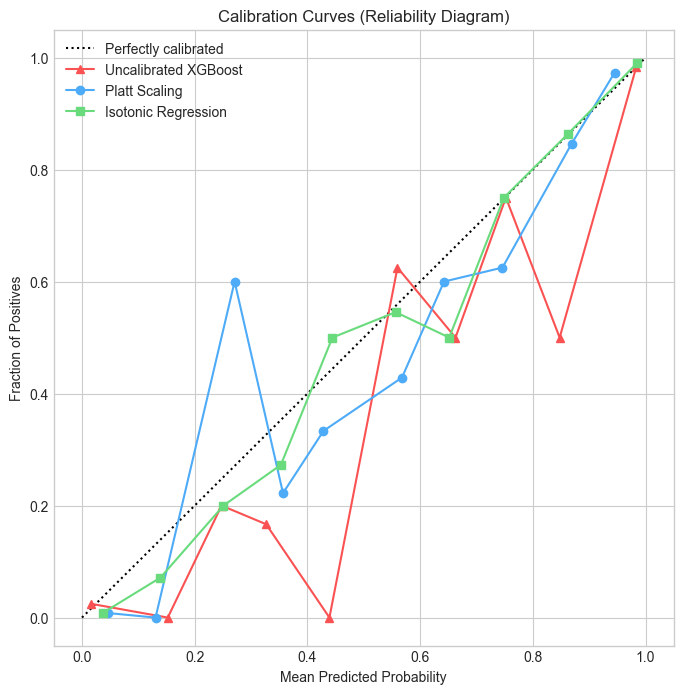

In [17]:
# 3. Visualize calibration
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 8))

disp1 = CalibrationDisplay.from_predictions(y_test, y_pred_proba_uncalibrated, n_bins=10, name='Uncalibrated XGBoost', ax=ax, marker='^', color='#fa5252')
disp2 = CalibrationDisplay.from_predictions(y_test, y_pred_proba_sigmoid, n_bins=10, name='Platt Scaling', ax=ax, marker='o', color='#4dabf7')
disp3 = CalibrationDisplay.from_predictions(y_test, y_pred_proba_isotonic, n_bins=10, name='Isotonic Regression', ax=ax, marker='s', color='#69db7c')

ax.set_title('Calibration Curves (Reliability Diagram)')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.legend()
plt.grid(True)
plt.show()

In [ ]:
#Brier score


In [ ]:
# Expected calibration error
